[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kevin-blasiak-curtin/ISYS2001-Archive/blob/main/Module%2008%20-%20API/lab_ticket_stock_chart.ipynb)

# Lab Ticket: Charting Real Stock Data

This week you used the Gemini API: you sent it text, and it sent text back. A stock service works the same way. You send a request (which company, what kind of data) and it sends back a structured response you can turn into a chart.

Your job is to fetch real stock data and draw one clear figure from it. The fetching is written for you. The figure is yours.

## The brief

**API to integrate:** Alpha Vantage (free).

Get your own key the same way you got your Gemini key:

1. Sign up at https://www.alphavantage.co/support/#api-key
2. Store it in Colab Secrets as `ALPHAVANTAGE_API_KEY`, with Notebook access switched on.

Use your own key, not the shared `demo` key. The demo key only ever returns data for IBM.

**Figure I expect:** a line chart of the daily closing price for one ticker of your choice, across the window the data covers. Label both axes, and give the chart a title that names the ticker.

**A note on limits:** the free key allows only about 25 requests a day. Run the fetch cell once. After that the data lives in a DataFrame called `prices`, so do all your charting from that. Re-running the fetch cell over and over will use up your daily quota, and you will start getting a notice instead of data.

In [8]:
from google.colab import userdata
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = userdata.get("ALPHAVANTAGE_API_KEY")


def get_stock_data(ticker):
    """Fetch daily prices for a ticker and return a tidy DataFrame.

    The result has a date index and Open, High, Low, Close and Volume columns,
    sorted from oldest to newest.
    """
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": ticker,
        "apikey": API_KEY,
        "outputsize": "compact",   # the most recent 100 trading days
    }

    response = requests.get(url, params=params)
    data = response.json()

    # If the expected data is missing, Alpha Vantage explains why here: an
    # invalid ticker, a missing key, or a note that you have hit the daily limit.
    if "Time Series (Daily)" not in data:
        reason = (data.get("Error Message")
                  or data.get("Note")
                  or data.get("Information")
                  or data)
        raise ValueError(f"No price data returned. Alpha Vantage said: {reason}")

    prices = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient="index")
    prices = prices.rename(columns={
        "1. open": "Open",
        "2. high": "High",
        "3. low": "Low",
        "4. close": "Close",
        "5. volume": "Volume",
    })
    prices = prices.astype(float)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.sort_index()
    return prices

In [9]:
# Run this once. Change the ticker to one of your choice.
prices = get_stock_data("AAPL")
prices.tail()

,Open,High,Low,Close,Volume
2026-09-21,335.280,339.64,333.05,338.98,34999229.0
2026-09-22,340.135,345.34,338.75,339.75,40711786.0
2026-09-23,341.075,341.80,335.50,337.02,31658823.0
2026-09-24,336.720,338.91,334.30,335.92,24733098.0
2026-09-25,336.040,341.67,334.53,341.07,30002507.0


In [15]:
# Import the Python SDK for Gemini API
!pip install -U google-generativeai
from google import generative_ai as genai
# Used to securely store your API key
from google.colab import userdata

# Ensure your GOOGLE_API_KEY is stored in Colab secrets
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

# Initialize the client and choose a model
client = genai.GenerativeModel(model='gemini-pro', api_key=GOOGLE_API_KEY)
MODEL = 'gemini-pro' # You can change this to another model if needed

ImportError: cannot import name 'generative_ai' from 'google' (/usr/local/lib/python3.13/dist-packages/google/__init__.py)

In [16]:
# Now, let's use the Gemini API to generate the chart code.

def ask_model_for_chart_code(prompt):
    try:
        response = client.generate_content(contents=prompt)
        return response.text
    except Exception as error:
        return f"Something went wrong talking to the API: {error}"

chart_prompt = "Generate python code using matplotlib and pandas to draw the daily closing price as a labelled line chart. Use a DataFrame named 'prices' that has a 'Close' column and a DatetimeIndex. Label both axes and give the chart a title that includes 'Daily Closing Price'."

generated_chart_code = ask_model_for_chart_code(chart_prompt)
print(generated_chart_code)

# You can then copy and paste the generated code into a new cell or execute it directly if it's clean.

Something went wrong talking to the API: name 'client' is not defined


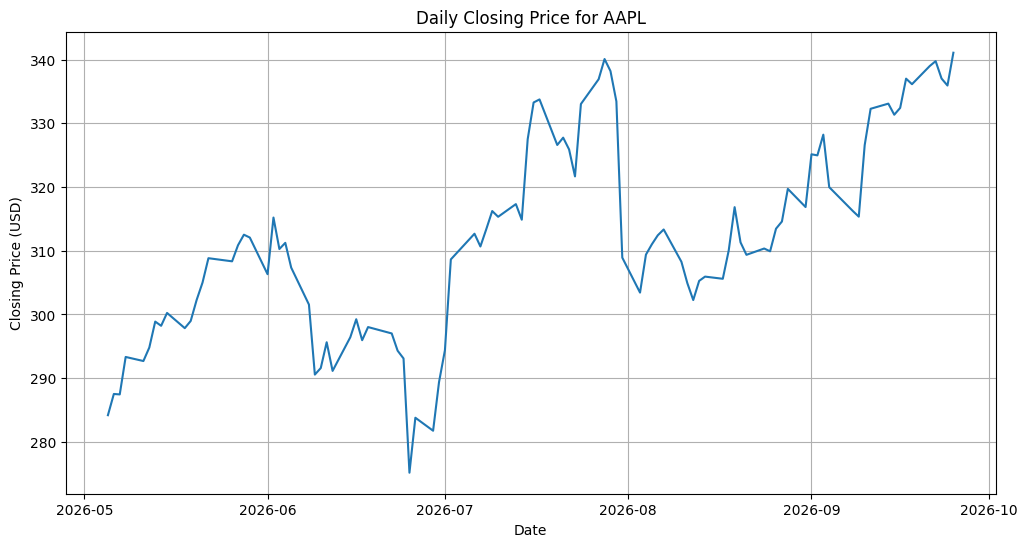

In [17]:
# Your chart from here.
# Draw the daily closing price as a labelled line chart, using the `prices` DataFrame.

# The previous code was attempting to use a generative model, which is not needed here.
# Instead, we will directly plot the prices using matplotlib.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices['Close'])
plt.title('Daily Closing Price for AAPL') # Assuming 'AAPL' as per the previous cell
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.show()

## Before you finish

Be ready to explain, in your own words:

- what the fetch returns, and what a single row represents
The fetch returns a pandas DataFrame, with the historical trading data for the specific stock ticker. A single row represents the trading performance for a single trading day. It records the opening price, highest price, lowest price, closing price, and total shares traded on that specific date.
- why a line chart suits this kind of data
A line chart suits this kind of data because it reflects the trends, momentum and fluctuations of the stocks over the period
- what your finished chart actually shows
The finished chart shows a rise in stocks based off of the historical data, being at a high for the closing price

**Stretch (optional):** add a second ticker to the same chart, or work out a simple moving average and plot it alongside the price. A moving average needs no extra request, since it is worked out from the data you already have.